## Data Acquisition
Pull dataset day by day dataset from cluster running at Birkbeck

In [3]:
%cd /home/roderick/workspace/mongo-cluster/prom-data/
%run pull.py

/home/roderick/workspace/mongo-cluster/prom-data
writing file latest-3.json for url: http://rrt-general-services.dcs.bbk.ac.uk:30233/api/v1/query_range?start=1699596000&end=1699682400&query=100%20-%20%281%20-avg%20by%20%28instance%29%20%281%20-%20rate%28node_cpu_seconds_total%7Binstance%3D~%22consumer-%5B0-9%5D%7B1%2C%7D%3A9091%7C%28data-writer-consumer-0%7Carnold-%28pri%7Csec-1%7Csec-2%29%7Cbairstow-%28pri%7Csec-1%7Csec-2%29%7Ccalvin-%28pri%7Csec-1%7Csec-2%29%7Cduncan-%28pri%7Csec-1%7Csec-2%29%7Celliot-%28pri%7Csec-1%7Csec-2%29%29%3A9091%22%2Cmode%3D%22idle%22%7D%5B25m%5D%29%29%20%2A%20100%29&step=10


ConnectionError: HTTPConnectionPool(host='rrt-general-services.dcs.bbk.ac.uk', port=30233): Max retries exceeded with url: /api/v1/query_range?start=1699596000&end=1699682400&query=100%20-%20%281%20-avg%20by%20%28instance%29%20%281%20-%20rate%28node_cpu_seconds_total%7Binstance%3D~%22consumer-%5B0-9%5D%7B1%2C%7D%3A9091%7C%28data-writer-consumer-0%7Carnold-%28pri%7Csec-1%7Csec-2%29%7Cbairstow-%28pri%7Csec-1%7Csec-2%29%7Ccalvin-%28pri%7Csec-1%7Csec-2%29%7Cduncan-%28pri%7Csec-1%7Csec-2%29%7Celliot-%28pri%7Csec-1%7Csec-2%29%29%3A9091%22%2Cmode%3D%22idle%22%7D%5B25m%5D%29%29%20%2A%20100%29&step=10 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f32fb55c910>: Failed to establish a new connection: [Errno -2] Name or service not known'))

## Data Manipulation

Note well that
* `dump-231104.tar.gz` showcases the time difference between the shards and clusters when processing a job.
* `dump-231111.tar.gz` showcases five separate runs together 

In [136]:
import pandas as pd
import os
import re

def file_rank(name):
    m = re.findall('(\d)', name)
    if (len(m) > 0):
        return int(m[0])
    return None

files = list(filter(lambda name: 'latest-' in name, os.listdir(".")))
files.sort(key = file_rank)
print(files)
frames = [pd.read_json(file) for file in files]

idx = list(map(lambda e: e['metric']['instance'].split(':')[0], frames[0]['data']['result']))

t = lambda df: list(map(lambda e: e[0], df['data']['result'][0]['values']))
# t = lambda df: list(map(lambda e: e[0], df['data']['result'][0]['values'])) # for original timestamp

a = pd.concat(
    [
        pd.DataFrame(
            dict(zip(idx, list(map(lambda e: e['values'], df['data']['result'])) )),
            index=t(df)
        )
        for df in frames
    ],
    ignore_index=False
)

for k in a.keys():
    a[k] = a[k].transform(lambda e: e[1])

# trimming the data by taking sices:
# a = a[24000:len(a)]

# sort on index
a.sort_index()

# output to sorted.csv for further processing
a.to_csv('sorted.csv')
a

['latest-1.json', 'latest-2.json', 'latest-3.json']


,arnold-pri,arnold-sec-1,arnold-sec-2,bairstow-pri,bairstow-sec-1,bairstow-sec-2,calvin-pri,calvin-sec-1,calvin-sec-2,consumer-0,...,consumer-6,consumer-7,consumer-8,consumer-9,duncan-pri,duncan-sec-1,duncan-sec-2,elliot-pri,elliot-sec-1,elliot-sec-2
1699423200,106.03143812709779,106.03311036789422,106.03177257525084,103.0204013377914,103.01973244145414,103.01806020068884,102.86086956519995,102.85919732437236,102.85953177255656,102.02876254176118,...,101.96588628761546,101.95919732442968,101.90568561875652,102.0060200668859,102.84949832774674,102.84916387959368,102.85016722408402,102.91170568561749,102.91137123749557,102.91237458195475
1699423210,106.02374581942166,106.03010033445439,106.02675585283035,103.02107023412867,103.01906354514801,103.01973244145414,102.8628762541806,102.86254180602755,102.8625418059964,102.02742474921122,...,101.96588628761546,101.95719063544901,101.90434782611312,102.00535117054864,102.8515050167274,102.85117056857433,102.85183946488046,102.90936454851492,102.91036789297411,102.91036789297411
1699423220,106.0301003344544,106.02742474916762,106.0301003344544,103.02240802677206,103.022073578619,103.0204013377914,102.86220735784335,102.86120401338417,102.86187290969028,102.02608695647439,...,101.96321070232868,101.95852842812356,101.90167224079521,102.00401337790525,102.85016722408402,102.8498327759621,102.85050167220592,102.91003344478989,102.90969899663683,102.91070234112716
1699423230,106.03076923076051,106.03143812712894,106.02775919732068,103.02408026753736,103.02173913040365,103.02173913043478,102.86354515048673,102.8628762541806,102.8628762541806,102.02809364551734,...,101.96187290965415,101.95852842812356,101.90568561872536,102.0060200668859,102.85016722408402,102.84983277593095,102.85117056857433,102.91103678931137,102.90936454851492,102.91170568561748
1699423240,106.02608695652424,106.03076923076051,106.03076923076051,103.02575250836495,103.02474916390577,103.02307692307818,102.86354515048673,102.86120401338415,102.8622073578122,102.0301003344357,...,101.96120401341032,101.95919732442968,101.90568561872536,102.00535117057979,102.8461538461227,102.84648829433806,102.84749163879724,102.91137123746442,102.90936454851492,102.91204013377055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699682360,106.15150501672491,106.14448160535491,106.14715719064169,198.95819397993313,198.95819397993313,198.95819397993313,103.082608695631,103.08160535117182,103.08294314378406,101.88896321066746,...,101.92508361203987,101.88093645486944,101.89498327760941,101.92107023410874,103.05150501674234,103.0515050167112,103.05250836120153,103.19230769229524,103.1929765886325,103.19163879598912
1699682370,106.14381270901764,106.15217391306217,106.144147157233,198.95785953178006,198.95785953178006,198.95785953178006,103.08193979932489,103.08127090298761,103.082608695631,101.88896321072976,...,101.92642140468227,101.88093645486944,101.89297658862877,101.91973244146536,103.04882943142442,103.04916387960864,103.05050167225201,103.19063545149879,103.18963210700846,103.19197324417333
1699682380,106.1461538461825,106.14381270901765,106.14682274245747,198.95785953178006,198.95785953178006,198.95785953178006,103.0809364548657,103.0809364548657,103.08193979935602,101.88762541805522,...,101.92575250836155,101.88026755850103,101.89364548496603,101.91973244146536,103.05050167228316,103.05050167222088,103.05150501674234,103.1913043478672,103.19096989965185,103.19331103678556
1699682390,106.14280936452732,106.14314381268038,106.14147157191508,198.9571906354428,198.95752508359584,198.9571906354428,103.082608695631,103.08160535117182,103.082608695631,101.88829431436135,...,101.92575250836155,101.88160535111327,101.89431438127215,101.91973244149649,103.05016722409896,103.05050167228316,103.05150501674234,103.1913043478049,103.1929765886325,103.19230769232638


## Analysis

[]

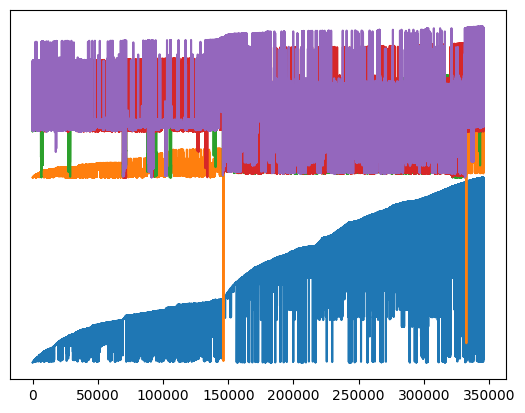

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
plt.plot(a['arnold-pri'])
plt.plot(a['bairstow-pri'])
plt.plot(a['calvin-pri'])
plt.plot(a['duncan-pri'])
plt.plot(a['elliot-pri'])
ax = plt.gca()
ax.set_yticks([])

/tmp/ipykernel_6945/613057701.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['avg-shard'] = data.aggregate(lambda row: np.mean((row['arnold-pri'], row['bairstow-pri'], row['calvin-pri'], row['duncan-pri'], row['elliot-pri']) / max_total_perf * 100), axis=1)
/tmp/ipykernel_6945/613057701.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['avg-consumer'] = data.aggregate(lambda row: np.mean((row['consumer-0'], row['consumer-1'], row['consumer-2'], row['consumer-3'], row['consumer-4'], row['c

Start Date: 2023-11-10 19:39:40
End Date: 2023-11-11 06:00:00


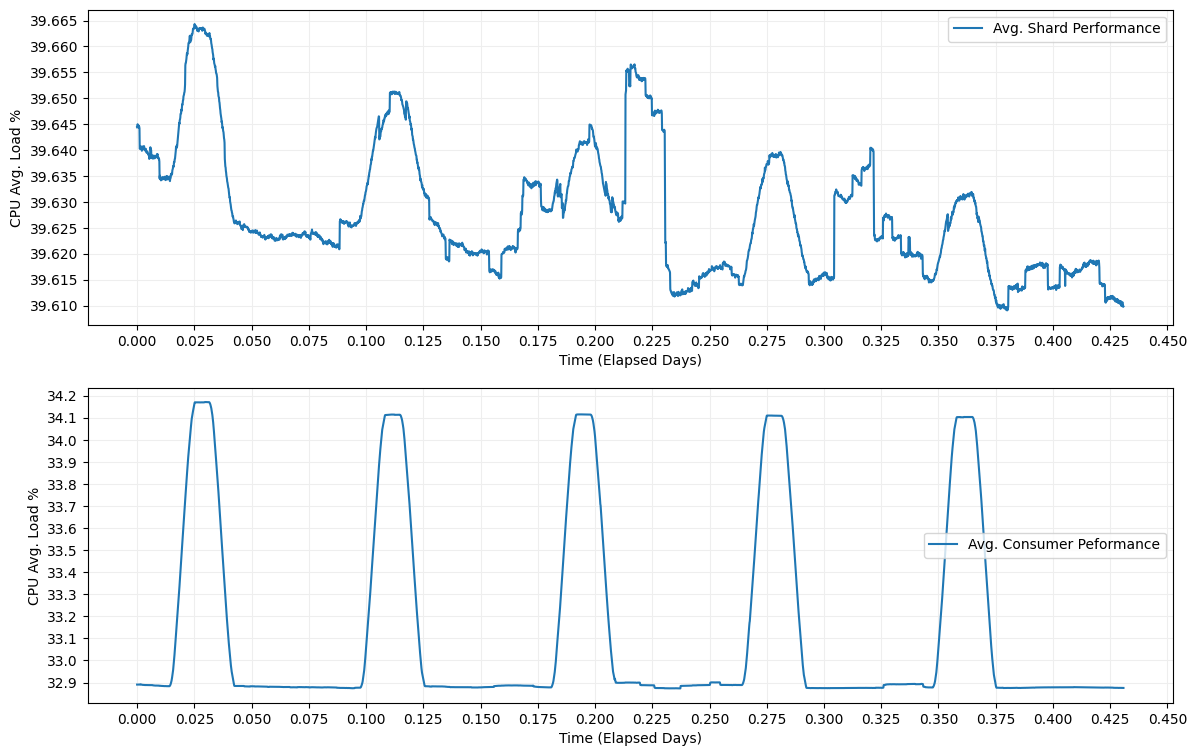

,arnold-pri,arnold-sec-1,arnold-sec-2,bairstow-pri,bairstow-sec-1,bairstow-sec-2,calvin-pri,calvin-sec-1,calvin-sec-2,consumer-0,...,duncan-pri,duncan-sec-1,duncan-sec-2,elliot-pri,elliot-sec-1,elliot-sec-2,avg-shard,avg-consumer,formatted_date,elapsed_sec
exec_day,,,,,,,,,,,,,,,,,,,,,
0.000000,106.567224,106.565886,106.563211,198.955853,198.955853,198.955853,103.120736,103.119732,103.120401,101.921739,...,103.081271,103.081605,103.081940,103.234448,103.234114,103.235117,39.644398,32.890646,2023-11-10 19:39:40,0
0.000116,106.565552,106.566890,106.570234,198.955518,198.955518,198.955518,103.122074,103.120736,103.122074,101.921739,...,103.081940,103.081940,103.083612,103.234783,103.235786,103.235452,39.644420,32.890835,2023-11-10 19:39:50,10
0.000231,106.571237,106.564883,106.571237,198.955184,198.955184,198.955184,103.121739,103.120067,103.122074,101.922408,...,103.082943,103.082943,103.083946,103.237458,103.236789,103.237124,39.644980,32.890646,2023-11-10 19:40:00,20
0.000347,106.565217,106.568562,106.566221,198.955518,198.955518,198.955518,103.121405,103.119732,103.120736,101.924415,...,103.082943,103.081940,103.083612,103.238796,103.236789,103.238127,39.644679,32.890700,2023-11-10 19:40:10,30
0.000463,106.565886,106.565552,106.569565,198.955518,198.955518,198.955518,103.119064,103.118395,103.119732,101.923746,...,103.083278,103.083278,103.084281,103.238796,103.239130,103.238796,39.644592,32.890659,2023-11-10 19:40:20,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.430324,106.151505,106.144482,106.147157,198.958194,198.958194,198.958194,103.082609,103.081605,103.082943,101.888963,...,103.051505,103.051505,103.052508,103.192308,103.192977,103.191639,39.610656,32.875473,2023-11-11 05:59:20,37180
0.430440,106.143813,106.152174,106.144147,198.957860,198.957860,198.957860,103.081940,103.081271,103.082609,101.888963,...,103.048829,103.049164,103.050502,103.190635,103.189632,103.191973,39.609815,32.875378,2023-11-11 05:59:30,37190
0.430556,106.146154,106.143813,106.146823,198.957860,198.957860,198.957860,103.080936,103.080936,103.081940,101.887625,...,103.050502,103.050502,103.051505,103.191304,103.190970,103.193311,39.610052,32.875257,2023-11-11 05:59:40,37200


In [3]:
#merged_frame.to_csv('data')
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd

data = data_in = pd.read_csv('sorted.csv', index_col=0)
data = data.tail(-22200)
#data = data.tail(-84000)
#data = data_in.drop(columns=("Unnamed: 0")).sort_index()

consumers = filter(lambda x: 'consumer' in x, data.keys())
max_shard_perf = np.max((data['arnold-pri'].max(), data['bairstow-pri'].max(), data['calvin-pri'].max(), data['duncan-pri'].max(), data['elliot-pri'].max()))
max_consumer_perf = np.max((data['consumer-0'], data['consumer-1'], data['consumer-2'], data['consumer-3'], data['consumer-4'], data['consumer-5'], data['consumer-6'], data['consumer-7'], data['consumer-8'], data['consumer-9'], data['consumer-10'], data['consumer-11'], data['consumer-12'], data['consumer-13'], data['consumer-14'], data['consumer-15'])).max()

max_total_perf = max_shard_perf + max_consumer_perf

# data['avg-shard'] = data.aggregate(lambda row: np.mean((row['arnold-pri'], row['bairstow-pri'], row['calvin-pri'], row['duncan-pri'], row['elliot-pri']) / max_shard_perf * 100), axis=1)
# data['avg-consumer'] = data.aggregate(lambda row: np.mean((row['consumer-0'], row['consumer-1'], row['consumer-2'], row['consumer-3'], row['consumer-4'], row['consumer-5'], row['consumer-6'], row['consumer-7'], row['consumer-8'], row['consumer-9'], row['consumer-10'], row['consumer-11'], row['consumer-12'], row['consumer-13'], row['consumer-14'], row['consumer-15']) / max_consumer_perf * 100), axis=1)
data['avg-shard'] = data.aggregate(lambda row: np.mean((row['arnold-pri'], row['bairstow-pri'], row['calvin-pri'], row['duncan-pri'], row['elliot-pri']) / max_total_perf * 100), axis=1)
data['avg-consumer'] = data.aggregate(lambda row: np.mean((row['consumer-0'], row['consumer-1'], row['consumer-2'], row['consumer-3'], row['consumer-4'], row['consumer-5'], row['consumer-6'], row['consumer-7'], row['consumer-8'], row['consumer-9'], row['consumer-10'], row['consumer-11'], row['consumer-12'], row['consumer-13'], row['consumer-14'], row['consumer-15']) / max_total_perf * 100), axis=1)

data['formatted_date'] = [datetime.datetime.fromtimestamp(entry).strftime("%Y-%m-%d %H:%M:%S") for entry in data.index]
final_timestamp = np.max(data.index)
first_timestamp = np.min(data.index)

print(f"Start Date: {datetime.datetime.fromtimestamp(first_timestamp)}")
print(f"End Date: {datetime.datetime.fromtimestamp(final_timestamp)}")

data['elapsed_sec'] = [entry - first_timestamp for entry in data.index]
#data['exec_day'] = [f"Day {(entry - 1693572880) // 86400} - {datetime.datetime.fromtimestamp(entry).strftime('%H:%M:%S')}" for entry in data.index]

#data['exec_day'] = [(entry - 1400000) / 86400.0  for entry in data.index]
data['exec_day'] = [entry / 86400.0  for entry in data['elapsed_sec']]
data = data.set_index('exec_day')

#a, b = 34300, 40000
# plt.plot(data['arnold-pri'][a:b], linewidth=0.5, color='#bb0000ff', linestyle='dotted', label="Arnold")
# plt.plot(data['bairstow-pri'][a:b], linewidth=0.5, linestyle='dotted')
# plt.plot(data['consumer-0'][a:b], linewidth=0.5, linestyle='dotted')
fig, (ax, ax2) = plt.subplots(2,1)
ax.plot(data['avg-shard'], linewidth=1.5, label='Avg. Shard Performance')
ax2.plot(data['avg-consumer'], linewidth=1.5, label='Avg. Consumer Peformance')
# ax.fill(data['avg-shard'], linewidth=1.5, color='#ccceff66')
# ax2.fill(data['avg-consumer'], linewidth=1.5, color='#ccceff66') # labels can be added.

fig.set_size_inches((14.0, 9.0))

ax.set_xlabel('Time (Elapsed Days)')
ax.set_ylabel('CPU Avg. Load %')
ax.grid(color='#eeeeee')
ax.legend()
ax.locator_params(axis='both', nbins = 20)

ax2.set_xlabel("Time (Elapsed Days)")
ax2.set_ylabel("CPU Avg. Load %")
ax2.grid(color='#eeeeee')
ax2.legend()
ax2.locator_params(axis='both', nbins = 20)

#plt.locator_params(axis='both', nbins = 20)
plt.show()
data

In [ ]:
from datetime import datetime
datetime.fromtimestamp(1694203210)
ticks

list(filter(lambda x: x[0] % 3 == 0, enumerate(ticks[1])))

[(0, Text(0, 0, '0')), (3, Text(3, 0, '4.3')), (6, Text(6, 0, '4.6'))]

## Individual Consumers (5 Experiments), Average Shape

* Note: the consumers averages plot show that a combination of these can be used as an summary performance metric (like a hash of the signals together $W$) - a mother wavelet $\Psi$ which can be decomposed into the individual signals being seen. While the data is not cyclical, the Fourier Transform of the signal $\hat{W}$ could be used in a similar way.

6400
[[[-1.47025859e-01-4.58957078e+01j  9.42221924e+00-7.33535605e+00j
   -2.61579217e-02+5.98309965e-02j ... -2.93718217e-01-6.51073000e-04j
   -2.60888336e-02-5.98098228e-02j  9.42006587e+00+7.33402270e+00j]
  [-1.55628044e-04-7.87149152e+01j  4.73821064e+01-3.42024348e+01j
    2.22524432e+01+8.65067306e+00j ...  3.68725780e-01-5.43854085e+00j
    2.22477626e+01-8.64843749e+00j  4.73712572e+01+3.41951699e+01j]
  [-1.33959158e-04-7.38923732e+01j  5.86922646e+01-2.86444701e+01j
    3.50669166e+01+2.89233552e+01j ... -7.72215971e+00-2.43158523e+01j
    3.50595058e+01-2.89164235e+01j  5.86787951e+01+2.86385476e+01j]
  ...
  [-5.70299278e-03-6.49867739e+01j  6.18034134e+01-1.98751042e+01j
    3.77217190e+01+5.25938597e+01j ... -3.83275103e+01-5.17338029e+01j
    3.77118496e+01-5.25882167e+01j  6.17946670e+01+1.98675757e+01j]
  [-5.97948684e-03-6.49881358e+01j  6.18076837e+01-1.98809291e+01j
    3.77395890e+01+5.26047472e+01j ... -3.83428434e+01-5.17743634e+01j
    3.77296803e+01-5.259947

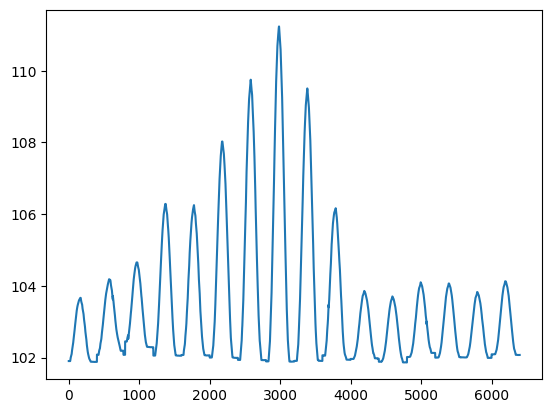

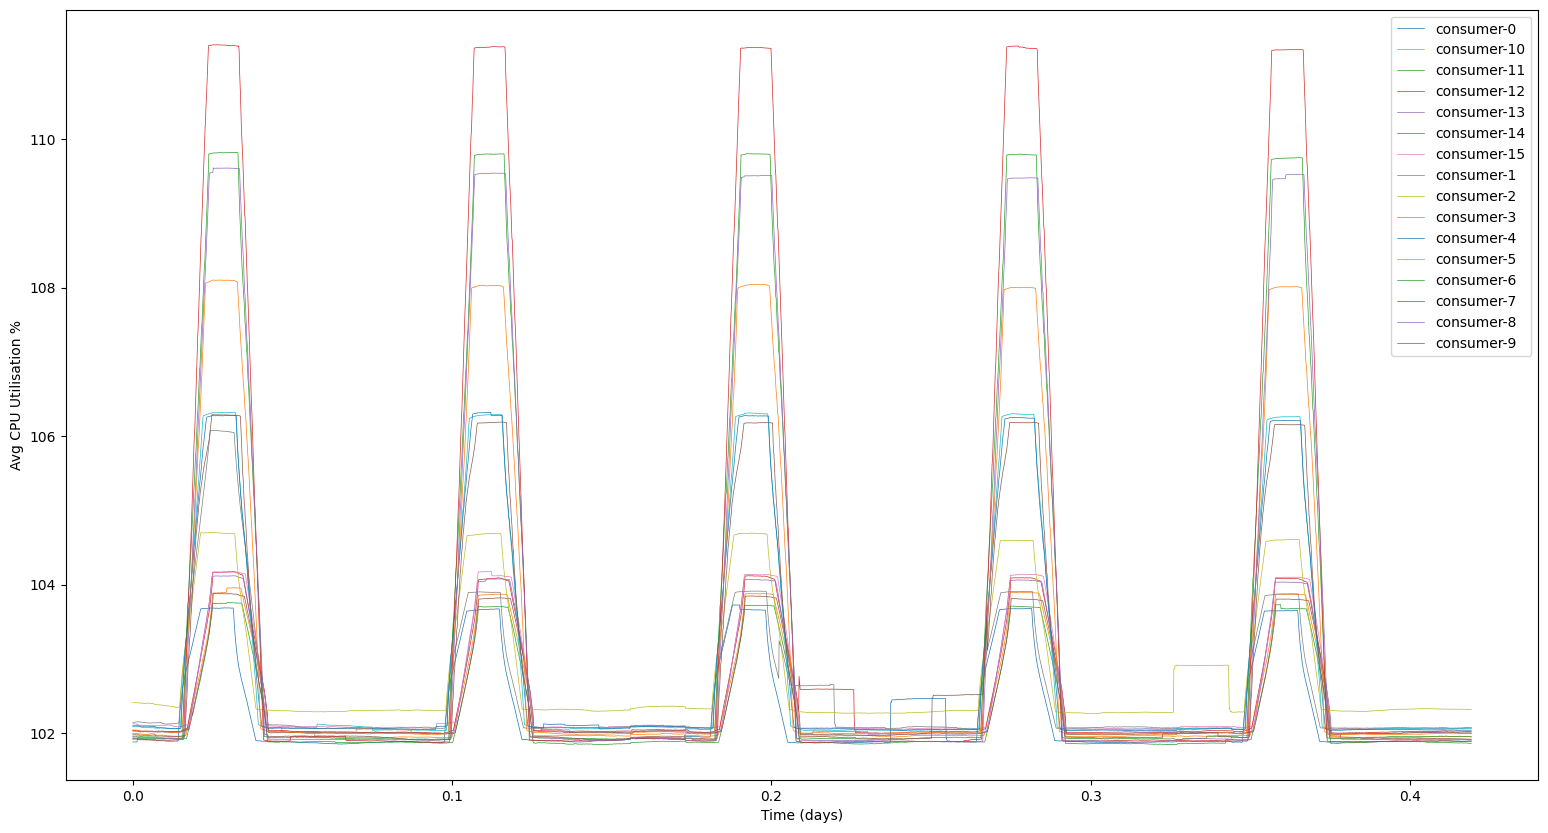

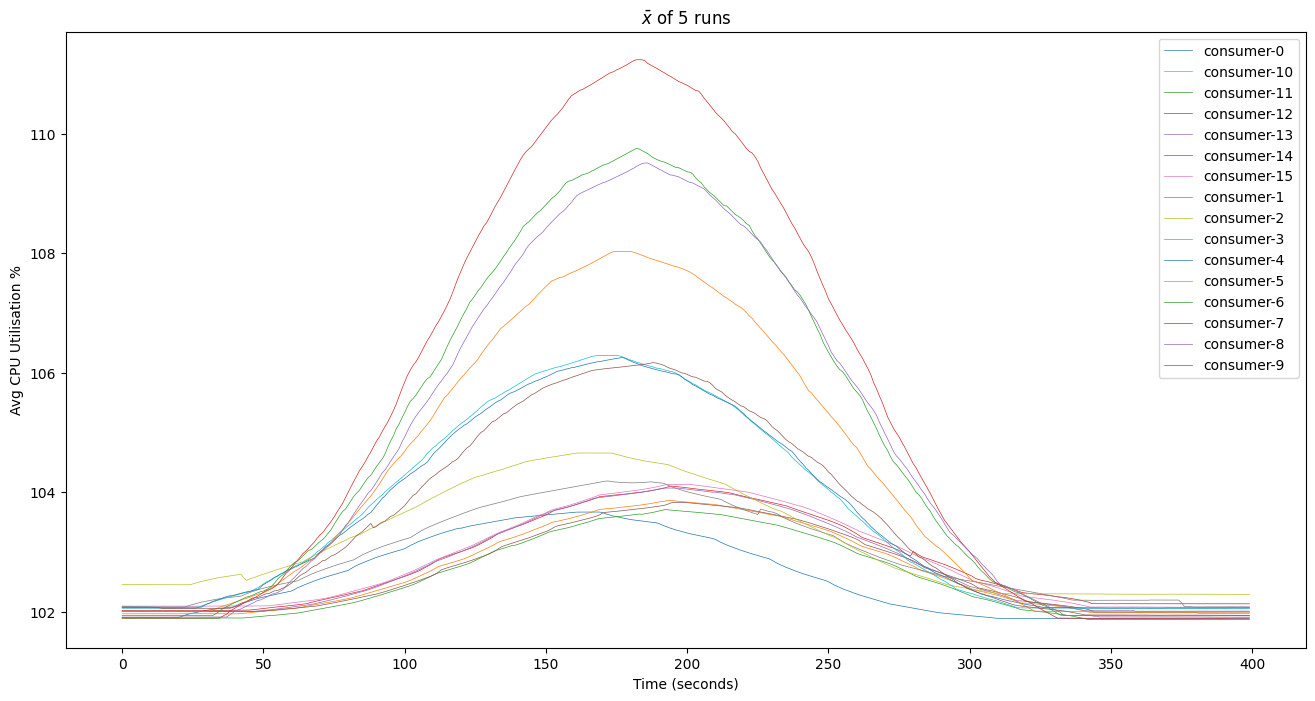

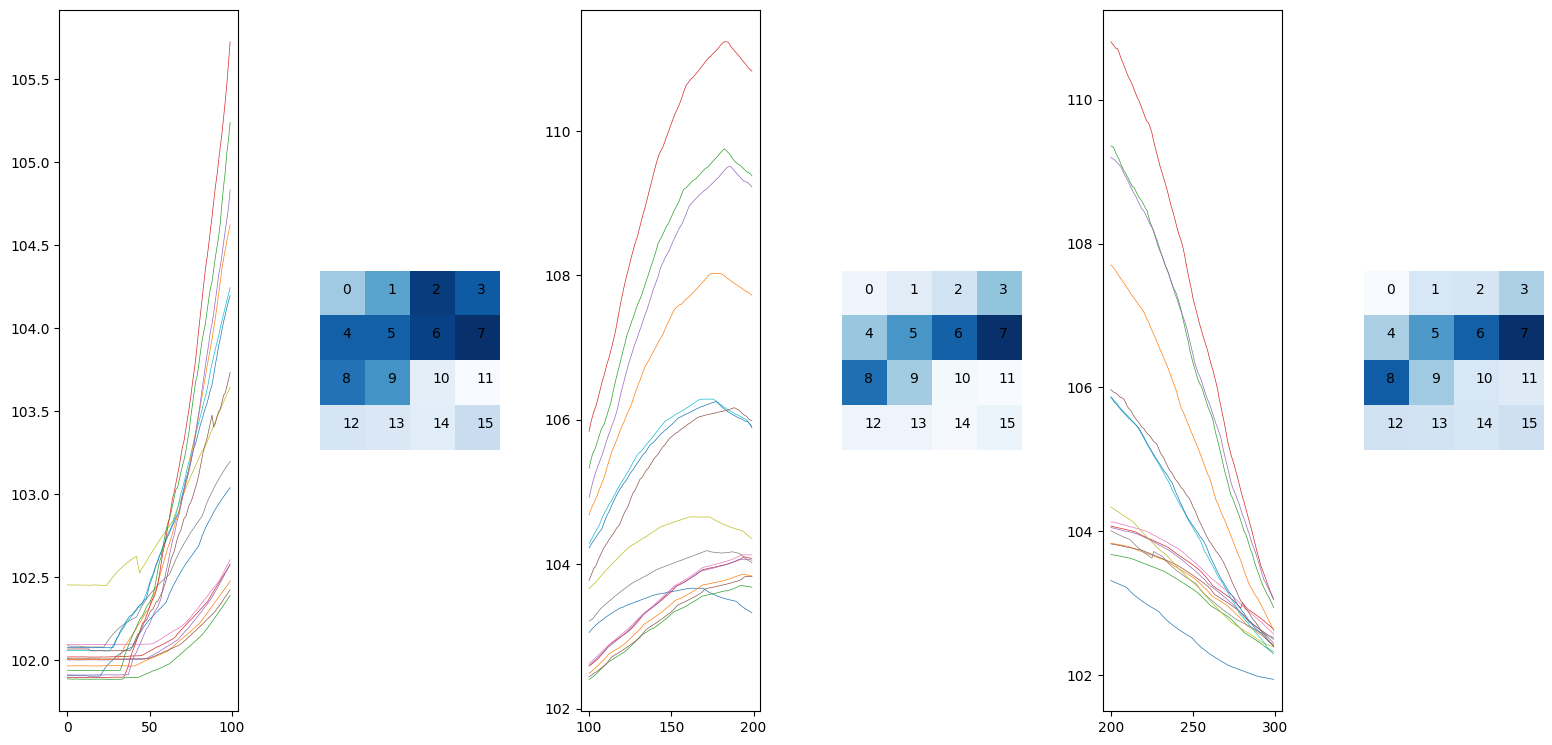

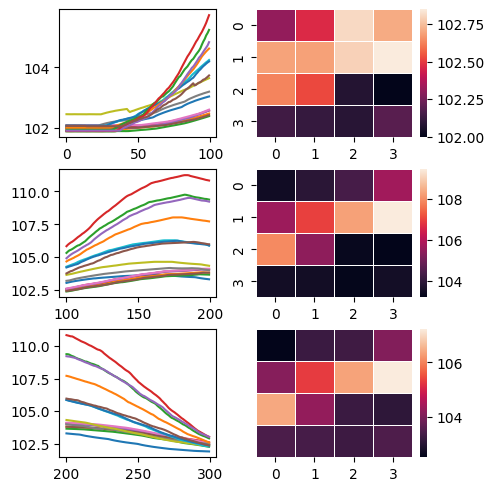

In [260]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import scipy.signal
import scipy.fft
import seaborn as sns

data = data_in = pd.read_csv('sorted.csv', index_col=0)
# data = data.tail(-22200)
ex1 = data.iloc[len(data_in) - 3700:len(data_in) - 3300]
ex2 = data.iloc[len(data_in) - 2900:len(data_in) - 2500]
ex3 = data.iloc[len(data_in) - 2200:len(data_in) - 1800]
ex4 = data.iloc[len(data_in) - 1500:len(data_in) - 1100]
ex5 = data.iloc[len(data_in) - 800:len(data_in) - 400]

# Mean of all 5 experiements
mean_consumer_df = pd.DataFrame()
for consumer in list(filter(lambda key: 'consumer-' in key, ex1.keys().values)):
    consumer_df = pd.DataFrame({
        '0': ex1[consumer].values,
        '1': ex2[consumer].values,
        '2': ex3[consumer].values,
        '3': ex4[consumer].values,
        '4': ex5[consumer].values
    })
    mean_consumer_df[consumer] = consumer_df.aggregate(lambda frame: np.mean(frame[:]), axis=1)

composite_df = pd.concat([mean_consumer_df[f"consumer-{i}"] for i in range(0, 16)], ignore_index=True)
figa, axa = plt.subplots(1, 1)
axa.plot(composite_df);
print(len(composite_df))



cwt_fn = lambda data: scipy.signal.cwt(data, scipy.signal.morlet, np.arange(1, 31))

cwt_matrix = np.array([
    cwt_fn(mean_consumer_df['consumer-0']),
    cwt_fn(mean_consumer_df['consumer-1']),
])
print(cwt_matrix)


# Consumer windows of activity at selected time points.

excerpt1 = mean_consumer_df.iloc[0:100]
excerpt2 = mean_consumer_df.iloc[100:200]
excerpt3 = mean_consumer_df.iloc[200:300]
excerpt1_heatmat = np.ndarray(shape=(4,4))
excerpt2_heatmat = np.ndarray(shape=(4,4))
excerpt3_heatmat = np.ndarray(shape=(4,4))

n = 0
for i in range(0, 4):
    for j in range(0, 4):
        excerpt1_heatmat[i][j] = excerpt1[f"consumer-{n}"].mean()
        excerpt2_heatmat[i][j] = excerpt2[f"consumer-{n}"].mean()
        excerpt3_heatmat[i][j] = excerpt3[f"consumer-{n}"].mean()
        n += 1
print(excerpt1_heatmat)


# print(ex1['consumer-0'].add(ex2['consumer-0']))
# data = ex1

#print(data.mean())

data['elapsed_sec'] = [entry - first_timestamp for entry in data.index]
data['exec_day'] = [entry / 86400.0  for entry in data['elapsed_sec']]
data = data.set_index('exec_day')

data.columns
consumers = data.iloc[22200:len(data) - 100, 9:25]

fig, ax = plt.subplots(1, 1)
ax.plot(consumers, linewidth=0.5, label=consumers.columns)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Avg CPU Utilisation %')
ax.legend()
fig.set_size_inches(19, 10)

fig2, ax2 = plt.subplots(1, 1)
fig2.set_size_inches(16, 8)
ax2.plot(mean_consumer_df, linewidth=0.5, label=mean_consumer_df.columns)
ax2.legend()
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Avg CPU Utilisation %')
ax2.set_title('$\\bar{x}$ of 5 runs')


fig3, (ax31, ax32, ax33, ax34, ax35, ax36) = plt.subplots(1, 6)
fig3.set_size_inches(16, 8)
fig3.tight_layout(pad=2.5)
ax31.plot(excerpt1, linewidth=0.5)
ax32.imshow(excerpt1_heatmat, cmap=matplotlib.cm.Blues)
[ax32.text(i, j, i + (j*4)) for i in range(0,4) for j in range(0,4)]

ax32.set_axis_off()
ax33.plot(excerpt2, linewidth=0.5)
ax34.matshow(excerpt2_heatmat, cmap=matplotlib.cm.Blues)
ax34.set_axis_off()
[ax34.text(i, j, i + (j*4)) for i in range(0,4) for j in range(0,4)]

ax35.plot(excerpt3, linewidth=0.5)
ax36.matshow(excerpt3_heatmat, cmap=matplotlib.cm.Blues)
ax36.set_axis_off()
[ax36.text(i, j, i + (j*4)) for i in range(0,4) for j in range(0,4)]

fig4 = plt.figure(layout='constrained')
gs = matplotlib.gridspec.GridSpec(3, 3, figure=fig4)
print(gs)
ax41 = fig4.add_subplot(gs[0,0])
ax42 = fig4.add_subplot(gs[1,0])
#ax43 = fig4.add_subplot(gs[0:-1,-2])
ax43 = fig4.add_subplot(gs[2,0])

ax41.plot(excerpt1)
ax42.plot(excerpt2)
ax43.plot(excerpt3)

ax44 = fig4.add_subplot(gs[0,-2])
#ax44.matshow(excerpt1_heatmat, cmap=matplotlib.cm.Blues); ax44.set_axis_off(); [ax44.text(i, j, i + (j*4)) for i in range(0,4) for j in range(0,4)]
sns.heatmap(excerpt1_heatmat, annot=False, linewidth=.5)

ax45 = fig4.add_subplot(gs[1,-2])
#ax45.matshow(excerpt2_heatmat, cmap=matplotlib.cm.Blues); ax45.set_axis_off(); [ax45.text(i, j, i + (j*4)) for i in range(0,4) for j in range(0,4)]
sns.heatmap(excerpt2_heatmat, annot=False, linewidth=.5)

ax46 = fig4.add_subplot(gs[2,-2])
#ax46.matshow(excerpt3_heatmat, cmap=matplotlib.cm.Blues); ax46.set_axis_off(); [ax46.text(i, j, i + (j*4)) for i in range(0,4) for j in range(0,4)]
sns.heatmap(excerpt3_heatmat, annot=False, linewidths=.5, yticklabels=[])


plt.show()
